# Fundamentos de Vectores y Embeddings

**Objetivo**: Entender qué son los vectores, cómo representan información, y por qué los embeddings son la tecnología fundamental detrás de sistemas RAG y búsqueda semántica.

**Contexto de aplicación**: Este notebook explora los conceptos que permiten construir búsqueda inteligente de repuestos en MINCA, donde un usuario puede buscar usando lenguaje natural y el sistema encuentra los productos más relevantes aunque no use exactamente las mismas palabras del catálogo.

**Conceptos clave que vamos a cubrir**:
- Qué es un vector y cómo representa información
- Métricas de similitud: distancia euclidiana vs similitud de coseno
- La maldición de la dimensionalidad y por qué más dimensiones no siempre es mejor
- Embeddings semánticos: convertir texto en vectores que capturan significado
- Búsqueda semántica en acción

---

## Parte 1: Vectores Básicos y Distancia Euclidiana

Un vector es simplemente una lista ordenada de números donde cada número representa alguna característica medible del objeto que estamos describiendo. Si queremos representar un repuesto usando solo dos características como peso y precio, podemos crear un vector de dos dimensiones donde la primera posición es el peso en kilogramos y la segunda posición es el precio en dólares.

La ventaja de representar objetos como vectores es que podemos usar matemáticas para medir qué tan similares son dos objetos. La forma más intuitiva de medir similitud es calcular la distancia entre dos puntos en el espacio vectorial. Si dos vectores están cerca uno del otro, significa que los objetos que representan tienen características similares.

In [ ]:
# Importar las librerías fundamentales que usaremos
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para que se vea bien
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ Librerías importadas correctamente")
print(f"NumPy version: {np.__version__}")

### Importando las Herramientas Necesarias

NumPy es la librería fundamental para trabajar con vectores y matrices en Python. Casi todas las operaciones que vamos a hacer con vectores se construyen sobre NumPy. Matplotlib nos permite visualizar los vectores en gráficos para desarrollar intuición visual de los conceptos.

Filtro de aceite: [ 0.5 15. ]
Amortiguador: [  3.2 120. ]
Tornillo: [0.02 2.  ]


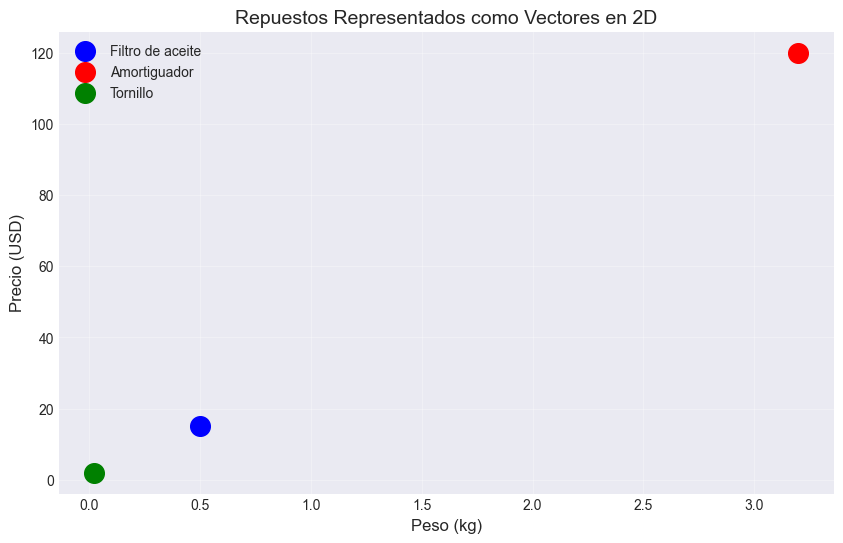

In [35]:
# Representemos tres repuestos usando vectores de 2 dimensiones
# Dimensión 1: peso en kilogramos
# Dimensión 2: precio en dólares

filtro_aceite = np.array([0.5, 15])    # Pesa 0.5kg, cuesta $15
amortiguador = np.array([3.2, 120])    # Pesa 3.2kg, cuesta $120
tornillo = np.array([0.02, 2])         # Pesa 0.02kg, cuesta $2

print("Filtro de aceite:", filtro_aceite)
print("Amortiguador:", amortiguador)
print("Tornillo:", tornillo)

# Visualicemos estos vectores en un plano cartesiano
plt.figure(figsize=(10, 6))
plt.scatter(filtro_aceite[0], filtro_aceite[1], s=200, c='blue', label='Filtro de aceite')
plt.scatter(amortiguador[0], amortiguador[1], s=200, c='red', label='Amortiguador')
plt.scatter(tornillo[0], tornillo[1], s=200, c='green', label='Tornillo')

plt.xlabel('Peso (kg)', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.title('Repuestos Representados como Vectores en 2D', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

### Observación Clave sobre el Gráfico

Cuando visualizamos los tres repuestos en el espacio bidimensional, podemos ver inmediatamente cuáles son más similares entre sí. El filtro de aceite y el tornillo están ambos relativamente cerca del origen porque son livianos y baratos, mientras que el amortiguador está lejos hacia la esquina superior derecha porque es pesado y caro.

Esta proximidad visual se traduce directamente en proximidad matemática. Podemos cuantificar exactamente qué tan cerca están dos vectores calculando la distancia euclidiana entre ellos.

In [21]:
def calcular_distancia_euclidiana(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    """
    Calcula la distancia euclidiana entre dos vectores.
    
    La distancia euclidiana es como medir con una regla en línea recta
    entre dos puntos. En 2D es simplemente el teorema de Pitágoras.
    
    Formula: sqrt((x1-x2)^2 + (y1-y2)^2 + ... + (yn-yn)^2)
    """
    diferencias = vector_a - vector_b
    diferencias_cuadradas = diferencias ** 2
    suma_cuadrados = np.sum(diferencias_cuadradas)
    distancia = np.sqrt(suma_cuadrados)
    
    return distancia

# Calculemos las distancias entre todos los pares de repuestos
dist_filtro_amortiguador = calcular_distancia_euclidiana(filtro_aceite, amortiguador)
dist_filtro_tornillo = calcular_distancia_euclidiana(filtro_aceite, tornillo)
dist_amortiguador_tornillo = calcular_distancia_euclidiana(amortiguador, tornillo)

print(f"Distancia entre filtro y amortiguador: {dist_filtro_amortiguador:.2f}")
print(f"Distancia entre filtro y tornillo: {dist_filtro_tornillo:.2f}")
print(f"Distancia entre amortiguador y tornillo: {dist_amortiguador_tornillo:.2f}")

print("\n¿Qué nos dice esto?")
print(f"El filtro está más cerca del tornillo ({dist_filtro_tornillo:.2f}) que del amortiguador ({dist_filtro_amortiguador:.2f})")
print("Esto tiene sentido porque el filtro y el tornillo son ambos livianos y baratos")

Distancia entre filtro y amortiguador: 105.03
Distancia entre filtro y tornillo: 13.01
Distancia entre amortiguador y tornillo: 118.04

¿Qué nos dice esto?
El filtro está más cerca del tornillo (13.01) que del amortiguador (105.03)
Esto tiene sentido porque el filtro y el tornillo son ambos livianos y baratos


### Interpretando las Distancias

Los números de distancia por sí solos no tienen un significado absoluto. Lo que importa es la comparación relativa. Una distancia de quince es mayor que una distancia de cinco, lo cual significa que esos dos objetos son menos similares entre sí.

En un sistema de búsqueda, cuando un usuario hace una consulta, convertiríamos su consulta en un vector y luego encontraríamos los productos cuya distancia al vector de consulta sea mínima. Esos serían los productos más relevantes para mostrarle al usuario.

In [22]:
# Vamos a trabajar con vectores de 5 dimensiones ahora
# Imagina que estas 5 dimensiones representan características como:
# [peso, precio, durabilidad, frecuencia_uso, importancia_critica]

filtro_5d = np.array([0.5, 15, 7, 8, 6])        # Liviano, barato, durable, uso frecuente, importante
amortiguador_5d = np.array([3.2, 120, 9, 3, 9]) # Pesado, caro, muy durable, uso poco frecuente, crítico
tornillo_5d = np.array([0.02, 2, 4, 9, 2])      # Muy liviano, muy barato, poco durable, uso muy frecuente, poco crítico
bujia_5d = np.array([0.1, 8, 5, 8, 7])         # Liviana, barata, durabilidad media, uso frecuente, bastante crítica

print("Ya no podemos visualizar estos vectores en un gráfico 2D,")
print("pero aún podemos calcular similitud perfectamente:\n")

# Calcular todas las distancias
from itertools import combinations

repuestos = {
    'Filtro': filtro_5d,
    'Amortiguador': amortiguador_5d,
    'Tornillo': tornillo_5d,
    'Bujía': bujia_5d
}

print("Distancias entre todos los pares de repuestos:")
print("-" * 50)

for (nombre1, vec1), (nombre2, vec2) in combinations(repuestos.items(), 2):
    distancia = calcular_distancia_euclidiana(vec1, vec2)
    print(f"{nombre1:15} ↔ {nombre2:15} : {distancia:6.2f}")

Ya no podemos visualizar estos vectores en un gráfico 2D,
pero aún podemos calcular similitud perfectamente:

Distancias entre todos los pares de repuestos:
--------------------------------------------------
Filtro          ↔ Amortiguador    : 105.22
Filtro          ↔ Tornillo        :  13.97
Filtro          ↔ Bujía           :   7.36
Amortiguador    ↔ Tornillo        : 118.51
Amortiguador    ↔ Bujía           : 112.24
Tornillo        ↔ Bujía           :   7.94


In [23]:
# Demostración de la maldición de la dimensionalidad
import numpy as np

def simular_distancias_por_dimension(num_puntos=100, dimensiones_a_probar=[2, 10, 50, 100, 500]):
    """
    Esta función genera puntos aleatorios en espacios de diferentes dimensiones
    y calcula las distancias promedio entre ellos para mostrar cómo cambia
    el comportamiento a medida que aumentas las dimensiones.
    """
    resultados = {}
    
    for dim in dimensiones_a_probar:
        # Generar puntos aleatorios en este espacio dimensional
        puntos = np.random.randn(num_puntos, dim)
        
        # Calcular todas las distancias par a par
        distancias = []
        for i in range(num_puntos):
            for j in range(i+1, num_puntos):
                dist = calcular_distancia_euclidiana(puntos[i], puntos[j])
                distancias.append(dist)
        
        distancias = np.array(distancias)
        resultados[dim] = {
            'promedio': np.mean(distancias),
            'std': np.std(distancias),
            'min': np.min(distancias),
            'max': np.max(distancias)
        }
    
    return resultados

# Ejecutar la simulación
print("Simulando distancias en espacios de diferentes dimensiones...")
print("Esto puede tomar unos segundos...\n")

resultados = simular_distancias_por_dimension()

print("Resultados:")
print("="*70)
print(f"{'Dimensiones':<15} {'Dist. Promedio':<20} {'Desv. Estándar':<20}")
print("="*70)

for dim, stats in resultados.items():
    print(f"{dim:<15} {stats['promedio']:<20.2f} {stats['std']:<20.2f}")

print("\n¿Qué observas?")
print("A medida que aumentan las dimensiones, la desviación estándar")
print("se vuelve más pequeña en relación al promedio. Esto significa que")
print("todas las distancias se vuelven más similares entre sí.")
print("Cuando todas las distancias son parecidas, perdemos la capacidad")
print("de distinguir qué puntos están realmente cerca y cuáles están lejos.")

Simulando distancias en espacios de diferentes dimensiones...
Esto puede tomar unos segundos...

Resultados:
Dimensiones     Dist. Promedio       Desv. Estándar      
2               1.83                 0.96                
10              4.24                 0.90                
50              10.00                1.01                
100             14.15                1.06                
500             31.74                1.03                

¿Qué observas?
A medida que aumentan las dimensiones, la desviación estándar
se vuelve más pequeña en relación al promedio. Esto significa que
todas las distancias se vuelven más similares entre sí.
Cuando todas las distancias son parecidas, perdemos la capacidad
de distinguir qué puntos están realmente cerca y cuáles están lejos.


## Parte 2: La Maldición de la Dimensionalidad

Aquí encontramos una de las paradojas más importantes del Machine Learning. Intuitivamente pensaríamos que más dimensiones siempre es mejor porque estamos capturando más aspectos diferentes de nuestros objetos. Y hasta cierto punto esto es verdad. Si solo usamos peso y precio, estamos ignorando completamente cosas como durabilidad, compatibilidad, marca, y docenas de otras características que podrían ser relevantes.

Sin embargo, a medida que añadimos más y más dimensiones, algo extraño empieza a pasar. En espacios de muy alta dimensionalidad, casi todos los puntos tienden a estar más o menos a la misma distancia unos de otros. Cuando todas las distancias son similares, perdemos la capacidad de distinguir qué puntos están realmente cerca y cuáles están lejos.

Además, cuando tienes muchas dimensiones, necesitas exponencialmente más datos para llenar ese espacio de forma significativa. Si en dos dimensiones necesitas cien puntos para tener buena cobertura, en diez dimensiones podrías necesitar millones de puntos para la misma densidad de información.

La simulación que acabamos de ejecutar demuestra esto numéricamente. Observa cómo la desviación estándar de las distancias se vuelve más pequeña en relación al promedio a medida que aumentamos las dimensiones. Esto indica que las distancias se vuelven más uniformes y por lo tanto menos informativas.

**Implicación práctica**: Más dimensiones no siempre es mejor. Solo añade dimensiones si contienen información útil y discriminatoria, y si tienes suficientes datos para soportar esa dimensionalidad.

In [24]:
# Simulación: ¿Qué pasa cuando añadimos más puntos de datos?

def generar_repuestos_sinteticos(cantidad, num_dimensiones=5):
    """
    Genera vectores sintéticos que simulan repuestos.
    Vamos a crear tres categorías distintas: eléctricos, mecánicos, y accesorios.
    Cada categoría tiene características típicas diferentes.
    """
    repuestos = []
    categorias = []
    
    for i in range(cantidad):
        # Decidir aleatoriamente a qué categoría pertenece este repuesto
        categoria = np.random.choice(['electrico', 'mecanico', 'accesorio'])
        
        if categoria == 'electrico':
            # Eléctricos: livianos, precio medio, durabilidad media, uso frecuente, importancia alta
            base = np.array([0.3, 40, 6, 7, 8])
            ruido = np.random.randn(num_dimensiones) * 0.5  # Pequeña variación aleatoria
            
        elif categoria == 'mecanico':
            # Mecánicos: pesados, caros, muy durables, uso poco frecuente, críticos
            base = np.array([2.5, 100, 9, 4, 9])
            ruido = np.random.randn(num_dimensiones) * 0.8
            
        else:  # accesorio
            # Accesorios: muy livianos, baratos, poco durables, uso variable, poca criticidad
            base = np.array([0.1, 10, 4, 6, 3])
            ruido = np.random.randn(num_dimensiones) * 0.6
        
        vector = base + ruido
        repuestos.append(vector)
        categorias.append(categoria)
    
    return np.array(repuestos), categorias

# Generar diferentes cantidades de repuestos
print("Generando conjuntos de datos de diferentes tamaños...\n")

for cantidad in [10, 50, 200, 1000]:
    vectores, cats = generar_repuestos_sinteticos(cantidad)
    
    print(f"\nCon {cantidad} repuestos:")
    print(f"  - Dimensiones del dataset: {vectores.shape}")
    print(f"  - Eléctricos: {cats.count('electrico')}")
    print(f"  - Mecánicos: {cats.count('mecanico')}")
    print(f"  - Accesorios: {cats.count('accesorio')}")
    
    # Calcular algunas estadísticas
    distancia_promedio_global = []
    for i in range(min(100, cantidad)):  # Solo calculamos para los primeros 100 para no tardar mucho
        for j in range(i+1, min(100, cantidad)):
            dist = calcular_distancia_euclidiana(vectores[i], vectores[j])
            distancia_promedio_global.append(dist)
    
    print(f"  - Distancia promedio entre repuestos: {np.mean(distancia_promedio_global):.2f}")

print("\n¿Qué observamos?")
print("Con más repuestos, tienes más ejemplos de cada categoría.")
print("Esto te permite hacer análisis estadísticos más robustos,")
print("encontrar patrones más confiables, y hacer predicciones más precisas.")
print("Pero las matemáticas fundamentales de distancias no cambian.")

Generando conjuntos de datos de diferentes tamaños...


Con 10 repuestos:
  - Dimensiones del dataset: (10, 5)
  - Eléctricos: 4
  - Mecánicos: 3
  - Accesorios: 3
  - Distancia promedio entre repuestos: 43.14

Con 50 repuestos:
  - Dimensiones del dataset: (50, 5)
  - Eléctricos: 17
  - Mecánicos: 17
  - Accesorios: 16
  - Distancia promedio entre repuestos: 41.54

Con 200 repuestos:
  - Dimensiones del dataset: (200, 5)
  - Eléctricos: 60
  - Mecánicos: 76
  - Accesorios: 64
  - Distancia promedio entre repuestos: 42.86

Con 1000 repuestos:
  - Dimensiones del dataset: (1000, 5)
  - Eléctricos: 336
  - Mecánicos: 350
  - Accesorios: 314
  - Distancia promedio entre repuestos: 41.72

¿Qué observamos?
Con más repuestos, tienes más ejemplos de cada categoría.
Esto te permite hacer análisis estadísticos más robustos,
encontrar patrones más confiables, y hacer predicciones más precisas.
Pero las matemáticas fundamentales de distancias no cambian.


### El Efecto de Más Datos

Añadir más ejemplos a tu conjunto de datos sí mejora la calidad de tus análisis porque tienes más ejemplos de cada tipo de patrón. Con solo tres repuestos puedes calcular distancias pero no puedes hacer generalizaciones estadísticas robustas. Con cien repuestos empiezas a ver agrupaciones naturales de productos similares. Con mil repuestos puedes entrenar modelos de machine learning que generalicen bien a datos nuevos.

Sin embargo, ten en cuenta que más datos solo ayuda si los datos son de buena calidad y representativos del dominio real. Mil ejemplos mal etiquetados o sesgados son peores que cien ejemplos de alta calidad.

---

## Parte 3: El Salto Conceptual - Embeddings Semánticos

Hasta ahora hemos trabajado con vectores donde nosotros decidimos manualmente qué significa cada dimensión. Peso en la primera posición, precio en la segunda, durabilidad en la tercera. Esto funciona pero tiene un problema gigante: requiere que sepas de antemano cuáles son las características importantes y que puedas medirlas numéricamente para cada objeto.

Ahora imagina un problema diferente. Tienes descripciones de repuestos escritas en lenguaje natural como "filtro de aceite sintético para motores diésel de alta eficiencia". ¿Cómo convertirías esta frase en un vector? No hay una forma obvia de asignar números a conceptos como "alta eficiencia" de manera que capturen el significado real de las palabras.

### ¿Qué Son los Embeddings?

Un embedding es un vector que representa el significado semántico de un texto. En lugar de que tú decidas manualmente qué medir en cada dimensión, un modelo de embeddings es una red neuronal entrenada con cantidades masivas de texto que aprendió automáticamente representaciones vectoriales donde textos con significados similares terminan cerca unos de otros en el espacio vectorial.

La parte alucinante es que estas representaciones capturan relaciones semánticas increíblemente sutiles. Por ejemplo, el vector para rey menos el vector para hombre más el vector para mujer está muy cerca del vector para reina. El modelo aprendió que la relación entre rey y hombre es análoga a la relación entre reina y mujer, sin que nadie programara explícitamente esa regla.

### ¿Cómo Se Entrenan Estos Modelos?

Los modelos de embeddings como sentence-transformers se entrenan con cientos de miles de millones de palabras de texto. El entrenamiento funciona mostrándole al modelo millones de pares de frases y enseñándole que ciertas frases son similares entre sí y otras no. Por ejemplo, "el gato duerme en el sofá" es semánticamente similar a "el felino descansa en el sillón" aunque usen palabras completamente diferentes.

Después de ver suficientes ejemplos, el modelo aprende a generar representaciones vectoriales donde la similitud geométrica en el espacio vectorial corresponde a similitud semántica en el significado real del texto.

### Dimensionalidad de los Embeddings

El modelo que vamos a usar genera vectores de setecientas sesenta y ocho dimensiones. Recuerda nuestra discusión sobre la maldición de la dimensionalidad. Setecientas sesenta y ocho es un número muy alto de dimensiones. La razón por la que funciona aquí es que este modelo fue entrenado con cantidades absolutamente masivas de texto, lo cual le permite usar esa alta dimensionalidad de forma efectiva.

Cada una de esas setecientas sesenta y ocho dimensiones captura algún aspecto del significado del texto. Tú no sabes exactamente qué representa cada dimensión, y francamente no necesitas saberlo. Lo que importa es que el modelo aprendió representaciones útiles donde textos similares están cerca en el espacio vectorial.

In [25]:
# Importar sentence-transformers para generar embeddings semánticos
from sentence_transformers import SentenceTransformer

# Cargar un modelo de embeddings pre-entrenado
# Este modelo específico está entrenado para español e inglés
# y genera vectores de 768 dimensiones
print("Cargando modelo de embeddings...")
print("Esto puede tomar un minuto la primera vez porque descarga el modelo...")

modelo = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f"\n✓ Modelo cargado exitosamente")
print(f"Dimensionalidad de los embeddings: {modelo.get_sentence_embedding_dimension()}")
print(f"Este modelo convierte cualquier texto en un vector de {modelo.get_sentence_embedding_dimension()} números")

Cargando modelo de embeddings...
Esto puede tomar un minuto la primera vez porque descarga el modelo...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ Modelo cargado exitosamente
Dimensionalidad de los embeddings: 384
Este modelo convierte cualquier texto en un vector de 384 números


In [28]:
# Descripciones de repuestos de MINCA
# Estas son descripciones realistas que podrían estar en tu catálogo
descripciones_repuestos = {
    'filtro_aceite_sintetico': "Filtro de aceite sintético de alta eficiencia para motores diésel modernos, compatible con vehículos pesados",
    'filtro_aceite_convencional': "Filtro de aceite convencional estándar para motores de gasolina, uso general en automóviles livianos",
    'amortiguador_delantero': "Amortiguador delantero de suspensión hidráulica para camiones de carga media, resistente a condiciones extremas",
    'amortiguador_trasero': "Amortiguador trasero de suspensión neumática para vehículos de transporte pesado, tecnología alemana",
    'bujia_platino': "Bujía de platino de larga duración para motores de gasolina de cuatro cilindros, alto rendimiento",
    'bujia_iridio': "Bujía de iridio premium para motores deportivos de alto rendimiento, máxima eficiencia de combustión",
    'pastilla_freno_ceramica': "Pastilla de freno de cerámica de alta temperatura para freno de disco delantero, bajo nivel de ruido",
    'pastilla_freno_metalica': "Pastilla de freno semi-metálica económica para uso urbano, freno trasero de vehículos livianos",
    'bateria_agm': "Batería AGM de ciclo profundo de 12 voltios y 100 amperios-hora para vehículos con alto consumo eléctrico",
    'bateria_convencional': "Batería de plomo-ácido convencional de 12 voltios y 60 amperios-hora para automóviles estándar"
}

print("Descripciones de repuestos cargadas:")
print("="*70)
for nombre, descripcion in descripciones_repuestos.items():
    print(f"\n{nombre}:")
    print(f"  {descripcion}")

Descripciones de repuestos cargadas:

filtro_aceite_sintetico:
  Filtro de aceite sintético de alta eficiencia para motores diésel modernos, compatible con vehículos pesados

filtro_aceite_convencional:
  Filtro de aceite convencional estándar para motores de gasolina, uso general en automóviles livianos

amortiguador_delantero:
  Amortiguador delantero de suspensión hidráulica para camiones de carga media, resistente a condiciones extremas

amortiguador_trasero:
  Amortiguador trasero de suspensión neumática para vehículos de transporte pesado, tecnología alemana

bujia_platino:
  Bujía de platino de larga duración para motores de gasolina de cuatro cilindros, alto rendimiento

bujia_iridio:
  Bujía de iridio premium para motores deportivos de alto rendimiento, máxima eficiencia de combustión

pastilla_freno_ceramica:
  Pastilla de freno de cerámica de alta temperatura para freno de disco delantero, bajo nivel de ruido

pastilla_freno_metalica:
  Pastilla de freno semi-metálica económ

### Interpretando los Embeddings

Los números que ves en los embeddings parecen aleatorios pero no lo son. Cada posición en ese vector de setecientas sesenta y ocho dimensiones representa alguna característica semántica que el modelo aprendió durante su entrenamiento. Algunas dimensiones podrían activarse fuertemente cuando el texto habla de vehículos pesados, otras cuando habla de eficiencia, otras cuando habla de componentes eléctricos versus mecánicos.

Lo importante es que no necesitas entender qué significa cada dimensión individualmente. El modelo aprendió representaciones donde la geometría del espacio vectorial refleja relaciones semánticas del lenguaje.

In [30]:
# Generar embeddings para todas las descripciones
print("Generando embeddings para todas las descripciones...")
print("Esto convierte cada texto en un vector de 384 números\n")

# Extraer solo las descripciones como una lista
textos = list(descripciones_repuestos.values())
nombres = list(descripciones_repuestos.keys())

# El modelo puede procesar múltiples textos a la vez, lo cual es muy eficiente
embeddings = modelo.encode(textos, show_progress_bar=True)

print(f"\n✓ Embeddings generados exitosamente")
print(f"Forma del array de embeddings: {embeddings.shape}")
print(f"Esto significa: {embeddings.shape[0]} repuestos, cada uno representado por {embeddings.shape[1]} números")

# Veamos cómo se ve el embedding de un solo repuesto
print(f"\nEjemplo - Embedding del filtro de aceite sintético:")
print(f"Primeros 10 valores: {embeddings[0][:10]}")
print(f"Últimos 10 valores: {embeddings[0][-10:]}")
print("\nCada uno de estos 384 números captura algún aspecto del significado semántico del texto")

Generando embeddings para todas las descripciones...
Esto convierte cada texto en un vector de 384 números



Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Embeddings generados exitosamente
Forma del array de embeddings: (10, 384)
Esto significa: 10 repuestos, cada uno representado por 384 números

Ejemplo - Embedding del filtro de aceite sintético:
Primeros 10 valores: [-0.1565326   0.30487597 -0.1639088   0.04019957  0.06300094  0.18595856
 -0.04622158  0.07169556 -0.11166481 -0.5462954 ]
Últimos 10 valores: [ 0.10487164 -0.2663697  -0.19715714 -0.12537196 -0.00057771  0.12080202
 -0.00749126 -0.04005919  0.5519028   0.18279809]

Cada uno de estos 384 números captura algún aspecto del significado semántico del texto


## Parte 4: Similitud de Coseno - La Métrica Correcta para Embeddings

Para embeddings, normalmente no usamos distancia euclidiana como hicimos con los vectores de características físicas. En su lugar usamos similitud de coseno, que mide el ángulo entre dos vectores en lugar de la distancia en línea recta entre ellos.

### ¿Por Qué Similitud de Coseno?

La similitud de coseno es invariante a la magnitud del vector. Solo le importa la dirección en la que apunta el vector en el espacio de alta dimensionalidad. Esto es útil porque en embeddings de texto, lo que queremos saber es si dos textos hablan de cosas similares, independientemente de cuán largo o corto sea el texto original.

Matemáticamente, la similitud de coseno entre dos vectores es el producto punto de los vectores dividido por el producto de sus magnitudes. El resultado es un número entre menos uno y uno:
- Uno significa que los vectores apuntan en exactamente la misma dirección (semánticamente idénticos)
- Cero significa que los vectores son completamente ortogonales (sin relación semántica)
- Menos uno significa que apuntan en direcciones opuestas (esto es raro en embeddings de texto)

En la práctica con embeddings de texto, casi siempre verás valores entre cero y uno.

In [31]:
def similitud_coseno(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    """
    Calcula la similitud de coseno entre dos vectores.
    
    La similitud de coseno mide el coseno del ángulo entre dos vectores.
    A diferencia de la distancia euclidiana, no le importa la magnitud de los vectores,
    solo su dirección en el espacio.
    
    Resultado entre -1 y 1:
      1.0 = vectores idénticos (mismo significado)
      0.0 = vectores ortogonales (sin relación)
     -1.0 = vectores opuestos (significados opuestos, raro en embeddings de texto)
    """
    # Producto punto de los dos vectores
    producto_punto = np.dot(vector_a, vector_b)
    
    # Magnitud (norma) de cada vector
    magnitud_a = np.linalg.norm(vector_a)
    magnitud_b = np.linalg.norm(vector_b)
    
    # Similitud de coseno
    similitud = producto_punto / (magnitud_a * magnitud_b)
    
    return similitud

# Ahora calculemos la similitud entre todos los pares de repuestos
print("Similitudes semánticas entre repuestos:")
print("="*80)

# Vamos a crear una matriz de similitudes
num_repuestos = len(nombres)
matriz_similitudes = np.zeros((num_repuestos, num_repuestos))

for i in range(num_repuestos):
    for j in range(num_repuestos):
        matriz_similitudes[i, j] = similitud_coseno(embeddings[i], embeddings[j])

# Mostrar la matriz de forma visual
import pandas as pd

df_similitudes = pd.DataFrame(
    matriz_similitudes,
    index=nombres,
    columns=nombres
)

print("\nMatriz de similitudes (1.0 = idénticos, 0.0 = sin relación):")
print(df_similitudes.round(3))

Similitudes semánticas entre repuestos:

Matriz de similitudes (1.0 = idénticos, 0.0 = sin relación):
                            filtro_aceite_sintetico  \
filtro_aceite_sintetico                       1.000   
filtro_aceite_convencional                    0.910   
amortiguador_delantero                        0.508   
amortiguador_trasero                          0.501   
bujia_platino                                 0.652   
bujia_iridio                                  0.722   
pastilla_freno_ceramica                       0.368   
pastilla_freno_metalica                       0.339   
bateria_agm                                   0.435   
bateria_convencional                          0.564   

                            filtro_aceite_convencional  \
filtro_aceite_sintetico                          0.910   
filtro_aceite_convencional                       1.000   
amortiguador_delantero                           0.497   
amortiguador_trasero                             0.455   
bu

### Interpretando la Matriz de Similitudes

La diagonal de la matriz siempre es uno porque cada repuesto es perfectamente similar a sí mismo. Los valores fuera de la diagonal nos dicen qué tan semánticamente similares son dos descripciones diferentes.

Observa cuidadosamente los patrones. Los dos filtros de aceite probablemente tienen una similitud alta entre ellos aunque uno sea sintético y otro convencional, porque ambos son fundamentalmente filtros de aceite. Las dos bujías también deberían tener similitud alta porque ambas son bujías para motores de gasolina aunque una sea de platino y otra de iridio.

Pero fíjate en la similitud entre un filtro de aceite y una batería. Aunque ambos son repuestos automotrices, cumplen funciones completamente diferentes y están hechos de materiales completamente diferentes. El modelo captura esto automáticamente mostrando una similitud mucho más baja entre ellos.

El modelo nunca fue entrenado específicamente con descripciones de repuestos de MINCA, pero aprendió representaciones tan ricas durante su entrenamiento masivo con texto general que puede capturar automáticamente estas relaciones semánticas.

## Parte 5: Búsqueda Semántica en Acción

Ahora vamos a simular exactamente lo que harías en un sistema RAG. Un usuario escribe una consulta en lenguaje natural buscando un producto. Convertimos esa consulta en un embedding y encontramos los productos cuyo embedding está más cerca usando similitud de coseno.

Lo poderoso de este enfoque es que el usuario no necesita usar exactamente las mismas palabras que están en las descripciones del catálogo. El modelo entiende el significado subyacente y encuentra los productos correctos basándose en similitud semántica, no en coincidencia exacta de palabras clave.

Este es el concepto fundamental detrás de la fase de recuperación en sistemas RAG. Tomas la pregunta del usuario, la conviertes en un embedding, buscas en una base de datos de embeddings pre-calculados de tus documentos o productos, encuentras los más similares usando similitud de coseno, y luego usas esos documentos relevantes como contexto para que un LLM genere una respuesta.

In [32]:
# Simulación de búsqueda semántica
# Esto es exactamente lo que harías en un sistema RAG

consultas_usuario = [
    "necesito un filtro para motor diésel de camión",
    "busco amortiguadores para vehículos pesados",
    "bujías de alto rendimiento para motor deportivo",
    "frenos cerámicos que no hagan ruido",
    "batería potente para vehículo con muchos accesorios eléctricos"
]

print("SIMULACIÓN DE BÚSQUEDA SEMÁNTICA")
print("="*80)

for consulta in consultas_usuario:
    print(f"\nConsulta del usuario: '{consulta}'")
    print("-"*80)
    
    # Convertir la consulta en un embedding
    embedding_consulta = modelo.encode([consulta])[0]
    
    # Calcular similitud con cada repuesto en nuestro catálogo
    similitudes = []
    for i, embedding_repuesto in enumerate(embeddings):
        sim = similitud_coseno(embedding_consulta, embedding_repuesto)
        similitudes.append((nombres[i], sim, descripciones_repuestos[nombres[i]]))
    
    # Ordenar por similitud de mayor a menor
    similitudes.sort(key=lambda x: x[1], reverse=True)
    
    # Mostrar los 3 resultados más relevantes
    print("\nTop 3 resultados más relevantes:")
    for rank, (nombre, sim, desc) in enumerate(similitudes[:3], 1):
        print(f"\n  {rank}. {nombre} (similitud: {sim:.3f})")
        print(f"     {desc}")

SIMULACIÓN DE BÚSQUEDA SEMÁNTICA

Consulta del usuario: 'necesito un filtro para motor diésel de camión'
--------------------------------------------------------------------------------

Top 3 resultados más relevantes:

  1. filtro_aceite_convencional (similitud: 0.753)
     Filtro de aceite convencional estándar para motores de gasolina, uso general en automóviles livianos

  2. filtro_aceite_sintetico (similitud: 0.731)
     Filtro de aceite sintético de alta eficiencia para motores diésel modernos, compatible con vehículos pesados

  3. amortiguador_delantero (similitud: 0.624)
     Amortiguador delantero de suspensión hidráulica para camiones de carga media, resistente a condiciones extremas

Consulta del usuario: 'busco amortiguadores para vehículos pesados'
--------------------------------------------------------------------------------

Top 3 resultados más relevantes:

  1. amortiguador_trasero (similitud: 0.717)
     Amortiguador trasero de suspensión neumática para vehículos

### Observaciones sobre los Resultados

Observa cuidadosamente cómo el modelo rankea los resultados. Cuando el usuario pregunta por un filtro para motor diésel de camión, el sistema debería identificar el filtro sintético que menciona motores diésel y vehículos pesados como el resultado más relevante, aunque el usuario no usó exactamente las palabras filtro sintético ni vehículos pesados.

El modelo entendió que camión es semánticamente similar a vehículo pesado, y que cuando alguien busca un filtro para motor diésel, probablemente quiere un filtro de aceite. Esta capacidad de entender intención y sinónimos es lo que hace que la búsqueda semántica sea tan poderosa comparada con búsqueda tradicional de palabras clave.

Reduciendo dimensionalidad de 768D a 2D para visualización...
Esto toma unos segundos...



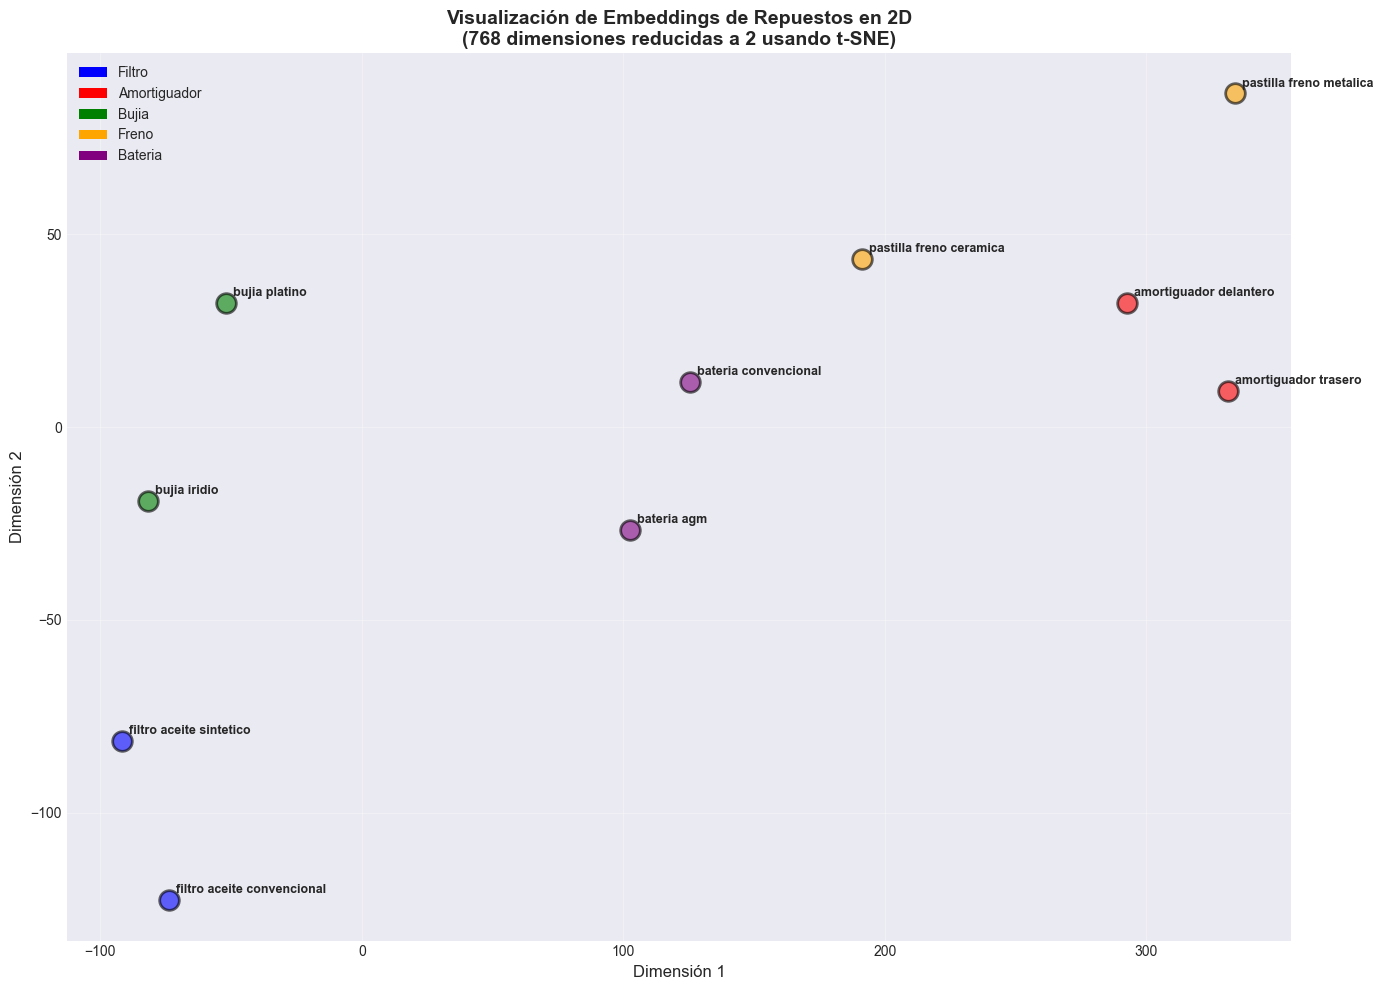


¿Qué observas en el gráfico?
Los repuestos de la misma categoría (mismo color) están agrupados cerca unos de otros.
Esto demuestra que los embeddings capturan similitud semántica automáticamente.
Los filtros están cerca de los filtros, las bujías cerca de las bujías, etc.


In [33]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reducir de 768 dimensiones a 2 dimensiones para visualización
print("Reduciendo dimensionalidad de 768D a 2D para visualización...")
print("Esto toma unos segundos...\n")

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
embeddings_2d = tsne.fit_transform(embeddings)

# Crear la visualización
plt.figure(figsize=(14, 10))

# Colores por categoría de repuesto
categorias = {
    'filtro': ['filtro_aceite_sintetico', 'filtro_aceite_convencional'],
    'amortiguador': ['amortiguador_delantero', 'amortiguador_trasero'],
    'bujia': ['bujia_platino', 'bujia_iridio'],
    'freno': ['pastilla_freno_ceramica', 'pastilla_freno_metalica'],
    'bateria': ['bateria_agm', 'bateria_convencional']
}

colores = {
    'filtro': 'blue',
    'amortiguador': 'red',
    'bujia': 'green',
    'freno': 'orange',
    'bateria': 'purple'
}

# Graficar cada punto
for i, nombre in enumerate(nombres):
    # Determinar categoría
    cat = None
    for categoria, items in categorias.items():
        if nombre in items:
            cat = categoria
            break
    
    color = colores.get(cat, 'gray')
    
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                c=color, s=200, alpha=0.6, edgecolors='black', linewidth=2)
    
    # Añadir etiqueta
    plt.annotate(nombre.replace('_', ' '), 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, weight='bold')

# Crear leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat.capitalize()) 
                   for cat, color in colores.items()]
plt.legend(handles=legend_elements, loc='best', fontsize=10)

plt.title('Visualización de Embeddings de Repuestos en 2D\n(768 dimensiones reducidas a 2 usando t-SNE)', 
          fontsize=14, weight='bold')
plt.xlabel('Dimensión 1', fontsize=12)
plt.ylabel('Dimensión 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n¿Qué observas en el gráfico?")
print("Los repuestos de la misma categoría (mismo color) están agrupados cerca unos de otros.")
print("Esto demuestra que los embeddings capturan similitud semántica automáticamente.")
print("Los filtros están cerca de los filtros, las bujías cerca de las bujías, etc.")

## Conclusiones y Próximos Pasos

### Lo Que Aprendimos

En este notebook cubrimos los conceptos fundamentales que necesitas para entender cómo funcionan los sistemas de búsqueda semántica y RAG:

Primero, entendimos que los vectores son simplemente listas de números que representan características de objetos, y que podemos medir similitud entre objetos calculando distancias entre sus vectores. Aprendimos sobre la distancia euclidiana como la medida más intuitiva de distancia geométrica en un espacio vectorial.

Segundo, descubrimos la maldición de la dimensionalidad, que nos enseña que más dimensiones no siempre es mejor. Existe un balance entre capturar suficiente información en tus vectores y no tener tantas dimensiones que los datos se vuelvan dispersos y las distancias pierdan significado.

Tercero, hicimos el salto conceptual más importante: entender que los embeddings son vectores que representan significado semántico de texto. Un modelo de embeddings pre-entrenado con cantidades masivas de texto aprendió automáticamente representaciones donde textos con significados similares están cerca en el espacio vectorial de alta dimensionalidad.

Cuarto, aprendimos que la similitud de coseno es la métrica correcta para comparar embeddings porque mide el ángulo entre vectores en lugar de la distancia en línea recta, lo cual es más apropiado en espacios de alta dimensionalidad.

Finalmente, vimos búsqueda semántica en acción, donde una consulta en lenguaje natural se convierte en un embedding y se buscan los documentos o productos más similares. Este es exactamente el patrón que usarás en sistemas RAG para recuperar contexto relevante antes de generar una respuesta con un LLM.

### Aplicación a MINCA

Para construir búsqueda semántica en el sistema de inventario de MINCA, necesitarías hacer lo siguiente:

Primero, pre-calcular embeddings para todas las descripciones de repuestos en tu catálogo una sola vez. Esto se hace offline y los embeddings se almacenan en una base de datos vectorial como pgvector en PostgreSQL.

Segundo, cuando un usuario hace una búsqueda, conviertes su consulta en un embedding usando el mismo modelo que usaste para generar los embeddings del catálogo.

Tercero, ejecutas una consulta de similitud de coseno contra la base de datos vectorial para encontrar los repuestos cuyos embeddings están más cerca del embedding de la consulta del usuario.

Cuarto, retornas esos repuestos como resultados de búsqueda, ordenados por similitud de mayor a menor.

Todo este proceso puede ejecutarse en milisegundos incluso con catálogos de decenas de miles de productos, y le da al usuario resultados increíblemente relevantes aunque no use exactamente las mismas palabras que están en tu catálogo.

### Próximos Pasos en el Roadmap

Este notebook representa el primer entregable de la Semana Uno, Día Uno y Dos. En los próximos días de la semana vamos a explorar modelos clásicos de Machine Learning como Regresión Logística, Random Forest y XGBoost, y vamos a construir un modelo de clasificación que prediga si un repuesto se va a agotar en los próximos siete días basándose en patrones históricos de movimiento de inventario.

Los conceptos de vectores y similitud que aprendimos aquí son fundamentales y van a aparecer una y otra vez a lo largo del roadmap de catorce semanas, desde RAG systems hasta modelos de predicción y sistemas de recomendación.